In [2]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from category_encoders import OrdinalEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)

    #High Cardinality
    #df.drop(columns=['building_id'],inplace=True) -> done for sqlite, renamed already for csv


    return df

In [4]:
df = wrangle();
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,
164002,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164081,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164089,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164098,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164103,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0


Model with Decision Tree, Tune Hyperparameter for model, Explain model prediction using jini importance
Three way split on data
Accuracy Score for Evaluation
Iterate: Ordinal Encoding for Categorical Feature, Validation Curve
Gini Importance

In [5]:
target = "severe_damage"
X = df.drop(columns=target)
y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
# Check your work
assert X_train.shape == (
    56668,
    11,
), f"The shape of `X_train` should be (56668, 11), not {X_train.shape}."
assert y_train.shape == (
    56668,
), f"The shape of `y_train` should be (56668,), not {y_train.shape}."
assert X_test.shape == (
    14168,
    11,
), f"The shape of `X_test` should be (14168, 11), not {X_test.shape}."
assert y_test.shape == (
    14168,
), f"The shape of `y_test` should be (14168,), not {y_test.shape}."

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [9]:
# Check your work
assert X_train.shape == (
    45334,
    11,
), f"The shape of `X_train` should be (45334, 11), not {X_train.shape}."
assert y_train.shape == (
    45334,
), f"The shape of `y_train` should be (45334,), not {y_train.shape}."
assert X_val.shape == (
    11334,
    11,
), f"The shape of `X_val` should be (11334, 11), not {X_val.shape}."
assert y_val.shape == (
    11334,
), f"The shape of `y_val` should be (11334,), not {y_val.shape}."

In [10]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.64


In [11]:
# Build Model
model = make_pipeline(
    OrdinalEncoder(), DecisionTreeClassifier(random_state=42)
)
# Fit model to training data
model.fit(X_train, y_train);

In [12]:
#Obtaining Accuracy Score in two different ways
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_val = model.score(X_val, y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 0.98
Validation Accuracy: 0.65


The Model is performing well for training but not validation set...means not generalizing ..we need to tune hyperparameters

In [13]:
#Depth is a hyperparameter as it determines the overfitting and generalizationn problem
tree_depth = model.named_steps['decisiontreeclassifier'].get_depth()
print("Tree Depth:", tree_depth)

Tree Depth: 49


In [14]:
depth_hyperparams = range(1,50,2)

In [15]:
# Check your work
assert (
    len(list(depth_hyperparams)) == 25
), f"`depth_hyperparams` should contain 25 items, not {len(list(depth_hyperparams))}."
assert (
    list(depth_hyperparams)[0] == 1
), f"`depth_hyperparams` should begin at 1, not {list(depth_hyperparams)[0]}."
assert (
    list(depth_hyperparams)[-1] == 49
), f"`depth_hyperparams` should end at 49, not {list(depth_hyperparams)[-1]}."

In [16]:
# Create empty lists for training and validation accuracy scores
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    # Create model with `max_depth` of `d`
    test_model = make_pipeline(
        OrdinalEncoder(), 
        DecisionTreeClassifier(max_depth=d,random_state=42)
    )
    # Fit model to training data
    test_model.fit(X_train, y_train)
    # Calculate training accuracy score and append to `training_acc`
    training_acc.append(test_model.score(X_train,y_train))
    # Calculate validation accuracy score and append to `training_acc`
    validation_acc.append(test_model.score(X_val, y_val))

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.7071072484228174, 0.7117395332421582, 0.7162394670666608]
Validation Accuracy Scores: [0.7088406564319746, 0.7132521616375508, 0.7166049055937886]


In [17]:
# Check your work
assert (
    len(training_acc) == 25
), f"`training_acc` should contain 25 items, not {len(training_acc)}."
assert (
    len(validation_acc) == 25
), f"`validation_acc` should contain 25 items, not {len(validation_acc)}."

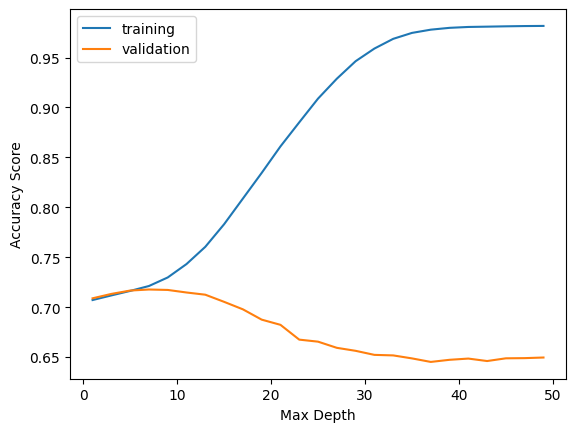

In [19]:
# Plot `depth_hyperparams`, `training_acc`
plt.plot(depth_hyperparams, training_acc,label="training")
plt.plot(depth_hyperparams, validation_acc,label="validation")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.legend();

Here we can confer the differences in the model accuracy. As depth increases the accuracy increases for training data...at Depth=6 the performance is same for both training and validation so we go for 6!

In [20]:
# Build Model With Tuned Hyperparameter
model = make_pipeline(
    OrdinalEncoder(), DecisionTreeClassifier(random_state=42,max_depth=6)
)
# Fit model to training data
model.fit(X_train, y_train);

In [21]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_val = model.score(X_val, y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 0.72
Validation Accuracy: 0.72


In [22]:
# Evalution on Test Data
test_acc = model.score(X_test, y_test)
print("Test Accuracy:", round(test_acc, 2))

Test Accuracy: 0.72


The Accuracy is close to training and validation data which is good!

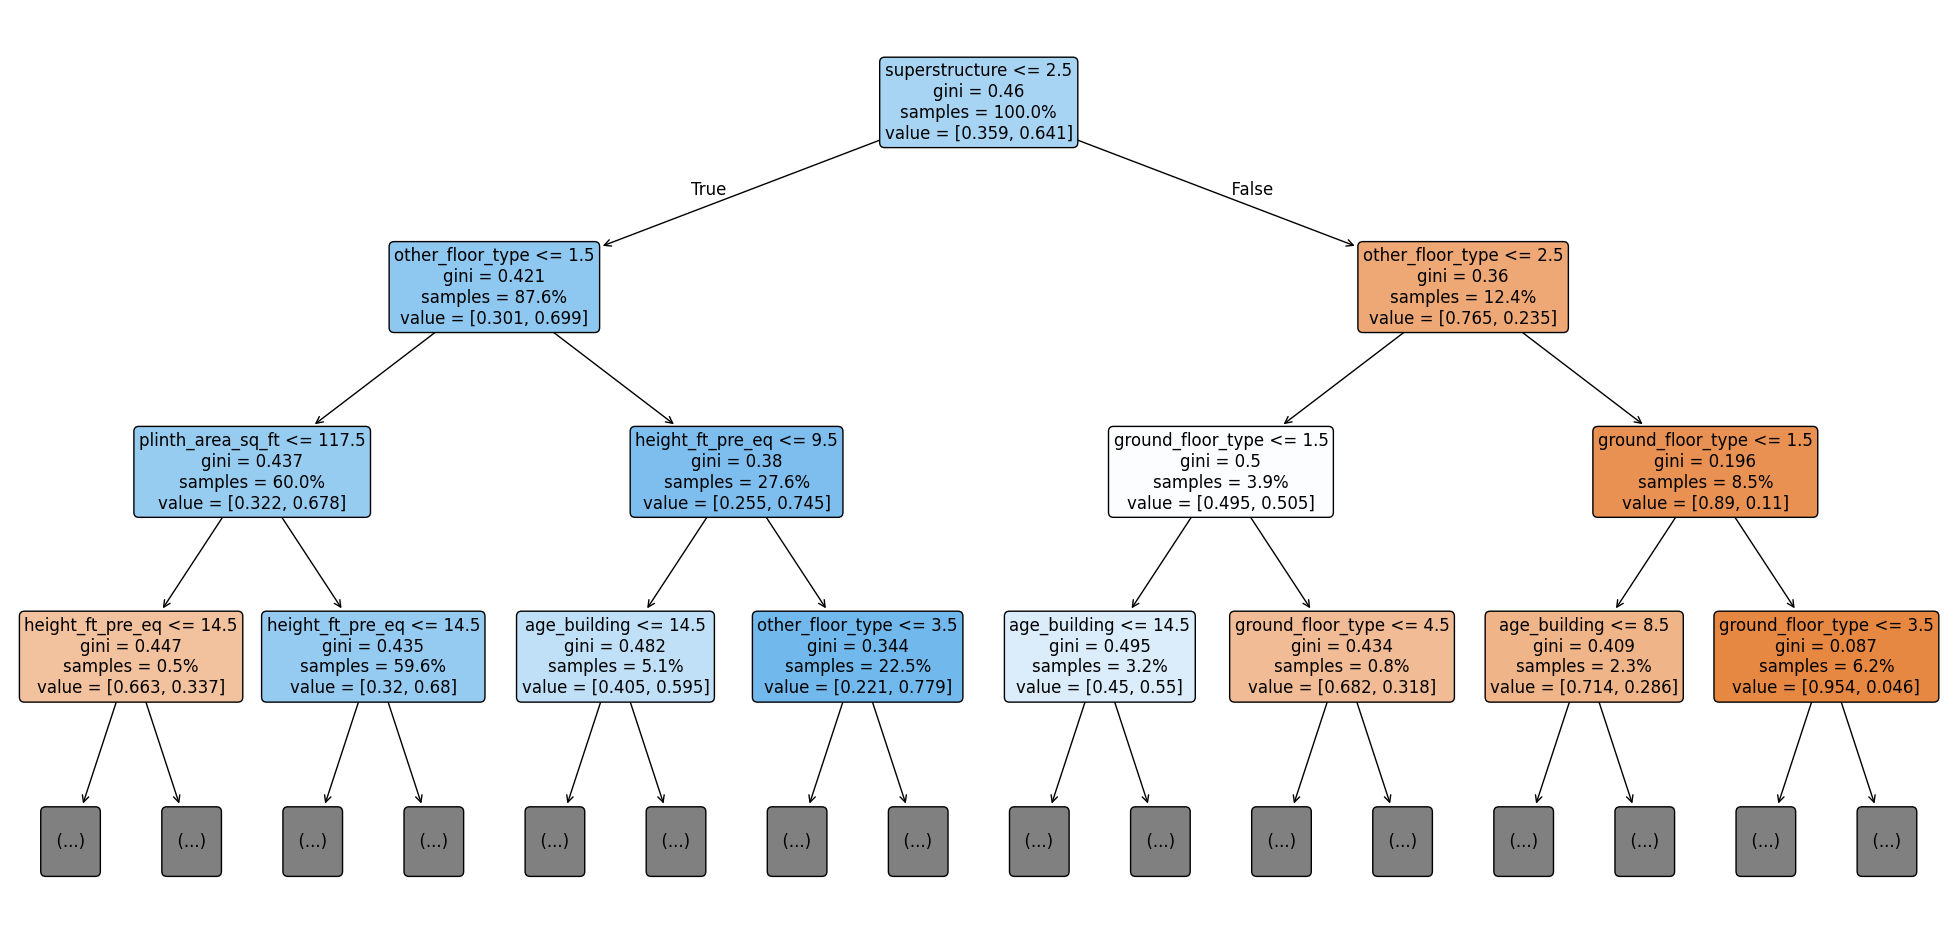

In [23]:
#Communication 
# Create larger figure
fig, ax = plt.subplots(figsize=(25, 12))
# Plot tree
plot_tree(
    decision_tree= model.named_steps["decisiontreeclassifier"],
    feature_names= X_train.columns.to_list(),
    filled=True,  # Color leaf with class
    rounded=True,  # Round leaf edges
    proportion=True,  # Display proportion of classes in leaf
    max_depth=3,  # Only display first 3 levels
    fontsize=12,  # Enlarge font
    ax=ax,  # Place in figure axis
);

In [24]:
features = X_train.columns
importances = model.named_steps["decisiontreeclassifier"].feature_importances_

print("Features:", features[:3])
print("Importances:", importances[:3])

Features: Index(['age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq'], dtype='object')
Importances: [0.03515085 0.04618639 0.08839161]


In [25]:
# Check your work
assert len(features) == 11, f"`features` should contain 11 items, not {len(features)}."
assert (
    len(importances) == 11
), f"`importances` should contain 11 items, not {len(importances)}."

In [26]:
feat_imp = pd.Series(importances, index=features).sort_values()
feat_imp.head()

position                  0.000644
plan_configuration        0.004847
foundation_type           0.005206
roof_type                 0.007620
land_surface_condition    0.020759
dtype: float64

In [27]:
feat_imp.sum()

np.float64(1.0)

Text(0, 0.5, 'Feature')

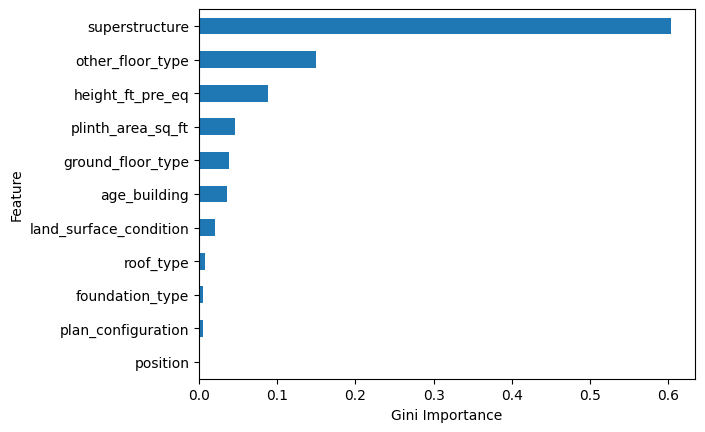

In [29]:
# Create horizontal bar chart
feat_imp.plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")

Here superstructure is responsible 60% decision to make impurity root to pure leaves process..